# Шаг 4. Кластеризация GMM на доменных шкалах C-BARQ

Вход: артефакты шагов 01–02 (`df_domains`, `df_domains_scaled`, `domain_scaler`, `domain_items`).

Сравнение с KMeans — в `05_clusters_compare.ipynb`.

In [12]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

import artifact_loader as my_lib

In [13]:
df_domains = pd.read_csv(my_lib.domain_data_path())
df_domains_scaled = pd.read_csv(my_lib.domain_scaled_data_path())
df_cbarq_clean = pd.read_csv(my_lib.df_cbarq_clean_path())
scaler = joblib.load(my_lib.domain_scaler_path())

with open(my_lib.domain_items_path(), encoding="utf-8") as f:
    DOMAIN_ITEMS = json.load(f)

domain_cols = df_domains.columns.tolist()
assert list(df_domains_scaled.columns) == domain_cols, "domain columns mismatch between raw and scaled"
assert len(df_domains) == len(df_domains_scaled) == len(df_cbarq_clean), "row count mismatch across artifacts"

X = df_domains_scaled[domain_cols].values

print(f"rows: {len(df_domains_scaled)}, domains: {len(domain_cols)}")
print(f"scaler: {my_lib.domain_scaler_path()}")
print(f"domain_items: {my_lib.domain_items_path()}")

rows: 775, domains: 13
scaler: /Users/l.tereshchenkova/MIPT/startup/notes/barko-docs/analytics/research/artifacts/models/domain_scaler.joblib
domain_items: /Users/l.tereshchenkova/MIPT/startup/notes/barko-docs/analytics/research/artifacts/json/domain_items.json


### GMM: подбор числа компонент k по BIC

Перебор `k = 2…8` на `X` (`df_domains_scaled`), `covariance_type="diag"`. Основной критерий — **BIC** (меньше = лучше).

Best k by BIC: 6 (BIC=15463.26)


,bic,aic,silhouette
k,,,
2,21960.58,21713.98,0.09
3,20194.75,19822.52,0.04
4,17909.38,17411.52,-0.01
5,16385.25,15761.77,-0.02
6,15463.26,14714.15,-0.02
7,15559.98,14685.24,-0.02
8,15642.14,14641.78,-0.07



Итого классов (компонент GMM): 6
Собак в кластерах: 775


,n_dogs
cluster_gmm,
0,35
1,260
2,211
3,54
4,147
5,68


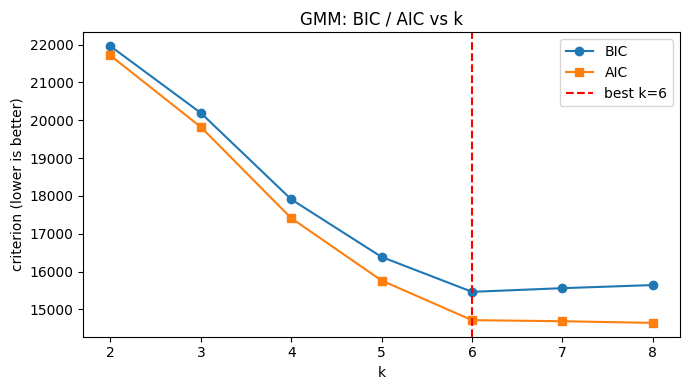

In [14]:
K_RANGE = range(2, 9)
RANDOM_STATE = 42
COVARIANCE_TYPE = "diag"

gmm_rows = []
models = {}

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type=COVARIANCE_TYPE,
        random_state=RANDOM_STATE,
        n_init=20,
        init_params='kmeans',
        warm_start=True,
    )
    gmm.fit(X)
    labels = gmm.predict(X)
    gmm_rows.append({
        "k": k,
        "bic": gmm.bic(X),
        "aic": gmm.aic(X),
        "silhouette": silhouette_score(X, labels),
    })
    models[k] = (gmm, labels)

gmm_df = pd.DataFrame(gmm_rows).set_index("k").round(2)
best_k = int(gmm_df["bic"].idxmin())
gmm_model, cluster_gmm = models[best_k]

print(f"Best k by BIC: {best_k} (BIC={gmm_df.loc[best_k, 'bic']:.2f})")
display(gmm_df)

cluster_sizes = (
    pd.Series(cluster_gmm, name="cluster_gmm")
    .value_counts()
    .sort_index()
    .to_frame("n_dogs")
)
print(f"\nИтого классов (компонент GMM): {best_k}")
print(f"Собак в кластерах: {cluster_sizes['n_dogs'].sum()}")
display(cluster_sizes)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(gmm_df.index, gmm_df["bic"], marker="o", label="BIC")
ax.plot(gmm_df.index, gmm_df["aic"], marker="s", label="AIC")
ax.axvline(best_k, color="red", linestyle="--", label=f"best k={best_k}")
ax.set_xlabel("k")
ax.set_ylabel("criterion (lower is better)")
ax.set_title("GMM: BIC / AIC vs k")
ax.set_xticks(list(K_RANGE))
ax.legend()
plt.tight_layout()
plt.show()

### Интерпретация GMM

- **Component means** на шкале 0–4 (`inverse_transform` от `gmm_model.means_`)
- **Размеры компонент** — hard labels (`predict`) и доли из `weights_`
- **`gmm_max_proba`** — уверенность в принадлежности к компоненте (soft assignment)

=== Размеры компонент ===


,n_dogs_hard,weight_model,pct_hard
cluster_gmm,,,
0,35,0.0466,0.0452
1,260,0.3480,0.3355
2,211,0.2723,0.2723
3,54,0.0681,0.0697
4,147,0.1759,0.1897
5,68,0.0892,0.0877



=== gmm_max_proba ===
775 dogs total
mean max proba: 0.957
median max proba: 1.000
uncertain (max_proba < 0.7): 48 (6.2%)


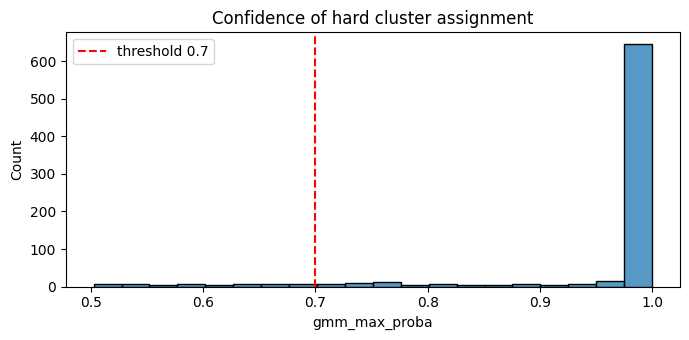


=== Component means (original 0–4 scale) ===


,trainability,stranger_directed_aggression,owner_directed_aggression,dog_directed_aggression,stranger_directed_fear,nonsocial_fear,dog_directed_fear,touch_sensitivity,separation_related,excitability,attachment,chasing,energy
component_0,1.71,0.34,0.56,1.44,0.95,1.34,0.98,1.10,0.63,1.76,1.98,1.94,1.08
component_1,1.48,0.53,0.00,1.34,1.10,1.14,0.99,0.66,0.64,2.03,2.35,2.21,1.58
component_2,1.43,0.00,0.00,0.95,0.00,0.72,0.53,0.47,0.42,1.85,2.34,2.25,1.72
component_3,1.44,0.77,0.30,1.35,0.92,1.11,0.62,0.30,0.67,2.29,2.77,2.20,1.89
component_4,1.49,0.38,0.35,1.43,0.00,0.91,0.46,0.55,0.64,2.01,2.40,2.26,1.75
component_5,1.43,1.31,0.87,2.04,1.58,1.61,1.72,1.20,1.04,2.78,2.87,2.82,2.02


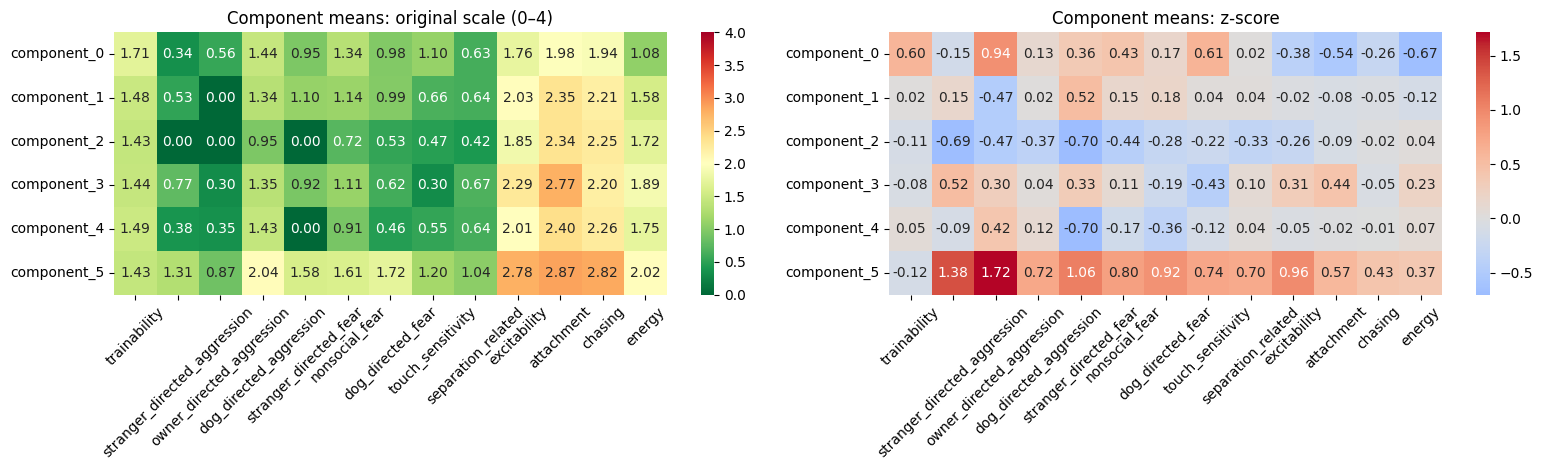

Saved: /Users/l.tereshchenkova/MIPT/startup/notes/barko-docs/analytics/research/artifacts/csv/clusters/df_domains_gmm.csv — 775 rows, 15 columns


In [15]:
gmm_proba = gmm_model.predict_proba(X)
gmm_max_proba = gmm_proba.max(axis=1)

component_means_scaled = pd.DataFrame(
    gmm_model.means_,
    index=[f"component_{i}" for i in range(best_k)],
    columns=domain_cols,
)
component_means_raw = pd.DataFrame(
    scaler.inverse_transform(gmm_model.means_),
    index=component_means_scaled.index,
    columns=domain_cols,
)

hard_sizes = (
    pd.Series(cluster_gmm, name="cluster_gmm")
    .value_counts()
    .sort_index()
    .rename("n_dogs_hard")
)
model_weights = (
    pd.Series(gmm_model.weights_, index=range(best_k), name="weight_model")
    .rename_axis("cluster_gmm")
)
component_sizes = (
    hard_sizes.to_frame()
    .join(model_weights)
    .assign(pct_hard=lambda df: df["n_dogs_hard"] / df["n_dogs_hard"].sum())
    .round(4)
)

print("=== Размеры компонент ===")
display(component_sizes)

print("\n=== gmm_max_proba ===")
print(component_sizes["n_dogs_hard"].sum(), "dogs total")
print(f"mean max proba: {gmm_max_proba.mean():.3f}")
print(f"median max proba: {np.median(gmm_max_proba):.3f}")
print(f"uncertain (max_proba < 0.7): {(gmm_max_proba < 0.7).sum()} ({(gmm_max_proba < 0.7).mean():.1%})")

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(gmm_max_proba, bins=20, ax=ax)
ax.axvline(0.7, color="red", linestyle="--", label="threshold 0.7")
ax.set_xlabel("gmm_max_proba")
ax.set_title("Confidence of hard cluster assignment")
ax.legend()
plt.tight_layout()
plt.show()

print("\n=== Component means (original 0–4 scale) ===")
display(component_means_raw.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, max(3.5, best_k * 0.8)))

sns.heatmap(
    component_means_raw,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    vmin=0,
    vmax=4,
    ax=axes[0],
)
axes[0].set_title("Component means: original scale (0–4)")
axes[0].tick_params(axis="x", rotation=45)

sns.heatmap(
    component_means_scaled,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    ax=axes[1],
)
axes[1].set_title("Component means: z-score")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# export
gmm_export = df_domains.copy()
gmm_export["cluster_gmm"] = cluster_gmm
gmm_export["gmm_max_proba"] = gmm_max_proba
out = my_lib.gmm_out_path()
out.parent.mkdir(parents=True, exist_ok=True)
gmm_export.to_csv(out, index=False)
print(f"Saved: {out} — {gmm_export.shape[0]} rows, {gmm_export.shape[1]} columns")

### Post-hoc: `breed_group` / `is_mixed` (не участвовали в GMM)

Распределение породы и метисности по компонентам `cluster_gmm`.

=== is_mixed by cluster_gmm (row %) ===


is_mixed,purebred,mixed
cluster_gmm,,
0,0.457,0.543
1,0.535,0.465
2,0.749,0.251
3,0.611,0.389
4,0.639,0.361
5,0.559,0.441



=== breed_group by cluster_gmm (row %) ===


breed_group,companion_toy,gundog,herding,mixed,molosser,other,pinscher_schnauzer,scenthound,sighthound,spitz_nordic,terrier,working
cluster_gmm,,,,,,,,,,,,
0,0.086,0.114,0.086,0.543,0.000,0.000,0.029,0.057,0.000,0.057,0.029,0.000
1,0.050,0.169,0.123,0.465,0.062,0.019,0.008,0.015,0.015,0.031,0.019,0.023
2,0.047,0.355,0.104,0.251,0.085,0.019,0.005,0.014,0.014,0.057,0.047,0.000
3,0.130,0.111,0.074,0.389,0.111,0.019,0.000,0.037,0.000,0.056,0.074,0.000
4,0.054,0.218,0.082,0.361,0.122,0.020,0.014,0.007,0.000,0.048,0.041,0.034
5,0.074,0.059,0.059,0.441,0.044,0.015,0.059,0.088,0.000,0.044,0.118,0.000


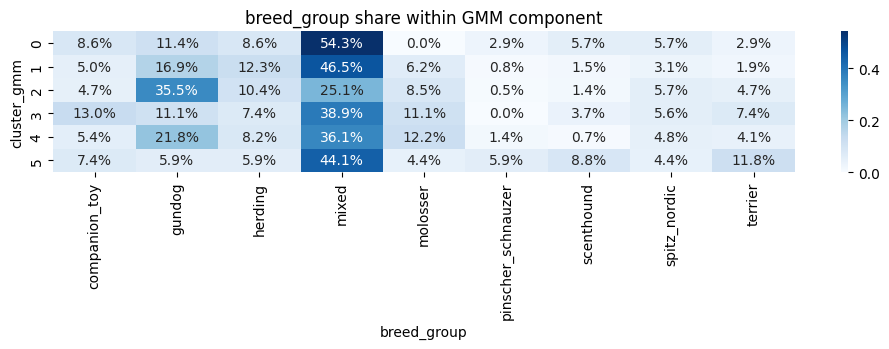


=== GMM component profile summary ===


,cluster_gmm,n,is_mixed_pct,gmm_max_proba_mean,top_breed_group,top_breed_group_pct,top2_breed_group,top3_breed_group
0,0,35,0.543,0.888,mixed,0.543,gundog,herding
1,1,260,0.465,0.979,mixed,0.465,gundog,herding
2,2,211,0.251,1.000,gundog,0.355,mixed,herding
3,3,54,0.389,0.895,mixed,0.389,companion_toy,molosser
4,4,147,0.361,0.895,mixed,0.361,gundog,molosser
5,5,68,0.441,0.963,mixed,0.441,terrier,scenthound


In [16]:
breed_group_cols = [c for c in df_cbarq_clean.columns if c.startswith("breed_group_")]
df_posthoc = df_cbarq_clean[["is_mixed"] + breed_group_cols].copy()
df_posthoc["cluster_gmm"] = cluster_gmm
df_posthoc["gmm_max_proba"] = gmm_max_proba

if breed_group_cols:
    df_posthoc["breed_group"] = (
        df_posthoc[breed_group_cols]
        .idxmax(axis=1)
        .str.removeprefix("breed_group_")
    )
    no_group = df_posthoc[breed_group_cols].sum(axis=1) == 0
    df_posthoc.loc[no_group, "breed_group"] = "unknown"
else:
    df_posthoc["breed_group"] = "unknown"

print("=== is_mixed by cluster_gmm (row %) ===")
display(
    pd.crosstab(df_posthoc["cluster_gmm"], df_posthoc["is_mixed"], normalize="index")
    .round(3)
    .rename(columns={0: "purebred", 1: "mixed"})
)

print("\n=== breed_group by cluster_gmm (row %) ===")
breed_ct = pd.crosstab(df_posthoc["cluster_gmm"], df_posthoc["breed_group"], normalize="index")
display(breed_ct.round(3))

active_groups = breed_ct.columns[(breed_ct.max(axis=0) >= 0.05)]
if len(active_groups) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3.5, best_k * 0.6)))
    sns.heatmap(breed_ct[active_groups], annot=True, fmt=".1%", cmap="Blues", ax=ax)
    ax.set_title("breed_group share within GMM component")
    plt.tight_layout()
    plt.show()

print("\n=== GMM component profile summary ===")
summary_rows = []
for cluster_id in sorted(df_posthoc["cluster_gmm"].unique()):
    sub = df_posthoc[df_posthoc["cluster_gmm"] == cluster_id]
    top_groups = sub["breed_group"].value_counts(normalize=True).head(3)
    summary_rows.append({
        "cluster_gmm": cluster_id,
        "n": len(sub),
        "is_mixed_pct": sub["is_mixed"].mean(),
        "gmm_max_proba_mean": sub["gmm_max_proba"].mean(),
        "top_breed_group": top_groups.index[0] if len(top_groups) else None,
        "top_breed_group_pct": top_groups.iloc[0] if len(top_groups) else np.nan,
        "top2_breed_group": top_groups.index[1] if len(top_groups) > 1 else None,
        "top3_breed_group": top_groups.index[2] if len(top_groups) > 2 else None,
    })

display(pd.DataFrame(summary_rows).round(3))